⏳ Loading datasets (this may take a minute due to file size)...


C:\Users\salma\AppData\Local\Temp\ipykernel_13224\2461035242.py:15: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(metadata_path)


🔗 Merging ratings with moves...
♟️  Extracting first moves...


C:\Users\salma\AppData\Local\Temp\ipykernel_13224\2461035242.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Skill Level', y='Entropy', data=entropy_df, order=level_order, palette="coolwarm")


✅ Success! Your analysis image is saved at: D:\Chess\final_opening_diversity.png


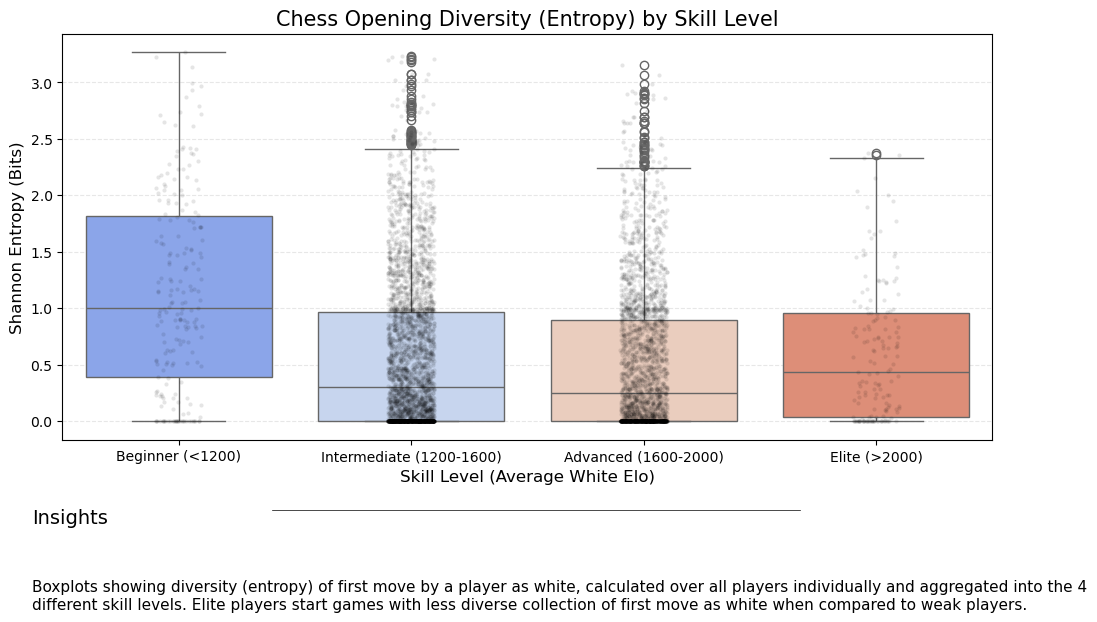

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import re
import os

# 1. Define Paths
folder_path = r"D:\Chess"
metadata_path = os.path.join(folder_path, "master_chess_data_2013_full.csv")
moves_path = os.path.join(folder_path, "full_moves_dataset_combined_2013.csv")

print("⏳ Loading datasets (this may take a minute due to file size)...")
df_meta = pd.read_csv(metadata_path)
df_moves = pd.read_csv(moves_path)

# 2. Merge them to get Elo and Moves in one place
# We merge on the common columns that identify a unique game
print("🔗 Merging ratings with moves...")
df = pd.merge(df_meta, df_moves, on=['White', 'Black', 'Date', 'Result'], how='inner')

# 3. Extract the first move for White
def extract_white_first_move(move_text):
    if pd.isna(move_text) or move_text == "":
        return None
    # Regex to find the move after '1.'
    match = re.search(r'1\.\s*([a-zA-Z0-9+#=/-]+)', move_text)
    if match:
        return match.group(1)
    return None

print("♟️  Extracting first moves...")
df['FirstMove'] = df['Moves'].apply(extract_white_first_move)

# 4. Filter and Calculate Entropy per Player
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df = df.dropna(subset=['FirstMove', 'WhiteElo', 'White'])

player_stats = []
# Group by player to see their individual "style"
for player, group in df.groupby('White'):
    if len(group) < 20: # Ensure we have enough games for a fair entropy score
        continue
    
    # Probability distribution of their first moves
    move_probs = group['FirstMove'].value_counts(normalize=True)
    shannon_ent = entropy(move_probs, base=2)
    avg_elo = group['WhiteElo'].mean()
    
    player_stats.append({
        'Player': player,
        'Entropy': shannon_ent,
        'AvgElo': avg_elo
    })

entropy_df = pd.DataFrame(player_stats)

# 5. Categorize into 4 Skill Levels
def get_skill_level(elo):
    if elo < 1200: return 'Beginner (<1200)'
    if elo < 1600: return 'Intermediate (1200-1600)'
    if elo < 2000: return 'Advanced (1600-2000)'
    return 'Elite (>2000)'

entropy_df['Skill Level'] = entropy_df['AvgElo'].apply(get_skill_level)

# 6. Create the Boxplot
plt.figure(figsize=(12, 7))
level_order = ['Beginner (<1200)', 'Intermediate (1200-1600)', 'Advanced (1600-2000)', 'Elite (>2000)']

sns.boxplot(x='Skill Level', y='Entropy', data=entropy_df, order=level_order, palette="coolwarm")
sns.stripplot(x='Skill Level', y='Entropy', data=entropy_df, order=level_order, color='black', alpha=0.1, size=3)

plt.title("Chess Opening Diversity (Entropy) by Skill Level", fontsize=15)
plt.ylabel("Shannon Entropy (Bits)", fontsize=12)
plt.xlabel("Skill Level (Average White Elo)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

line = plt.Line2D([0.3, 0.74], [0.2, 0.2], transform=plt.gcf().transFigure, color='black', linewidth=0.5)
plt.gcf().lines.append(line)

# 2. Adjust the layout to leave room at the bottom
plt.subplots_adjust(bottom=0.3)

# 3. Add the Title "Insights" (Non-bold)
plt.figtext(0.1, 0.18, "Insights", fontsize=14, ha='left')

# 4. Add the descriptive text (Non-bold, wrapped)
insight_text = ("Boxplots showing diversity (entropy) of first move by a player as white, "
                "calculated over all players individually and aggregated into the 4 different skill levels. "
                "Elite players start games with less diverse collection of first move as white when compared to weak players.")

plt.figtext(0.1, 0.1, insight_text, fontsize=11, ha='left', va='top', wrap=True)

# Save the final result
save_img = os.path.join(folder_path, "final_opening_diversity.png")
plt.savefig(save_img, bbox_inches='tight')
print(f"✅ Success! Your analysis image is saved at: {save_img}")
plt.show()

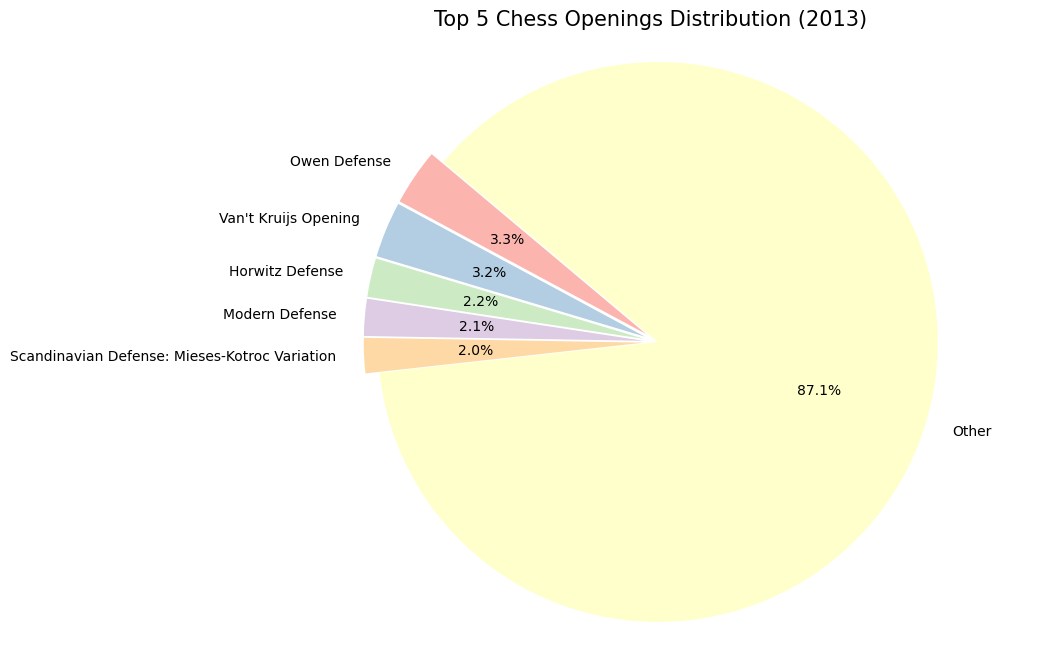

In [10]:
# 2. Get the frequency of each opening
opening_counts = df['Opening'].value_counts()

# 3. Separate the top 5 and group the rest into "Other"
top_5 = opening_counts.head(5)
other_count = opening_counts.iloc[5:].sum()

# 4. Create a combined Series for the pie chart
plot_data = pd.concat([top_5, pd.Series({'Other': other_count})])

# 5. Plotting
plt.figure(figsize=(10, 8))
colors = plt.cm.Pastel1(range(len(plot_data)))

# Create the pie chart
plt.pie(
    plot_data, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=[0.05 if i < 5 else 0 for i in range(len(plot_data))] # Explode top 5 slightly
)

plt.title('Top 5 Chess Openings Distribution (2013)', fontsize=15)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Optional: Save the figure
plt.savefig(r"D:\Chess\top_5_openings_pie.png", bbox_inches='tight')
plt.show()

In [10]:
# Ensure Elo is numeric
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')

# 2. Group by Player and Opening to get counts and their average rating
# We use 'mean' for Elo to get their general skill level during this period
player_stats = df.groupby(['White', 'Opening']).agg(
    Times_Played=('Opening', 'count'),
    Avg_Elo=('WhiteElo', 'mean')
).reset_index()

# 3. Identify the favorite opening (the one with the highest count)
# Sort by Player (alphabetical) and then Times_Played (descending)
favorite_openings = player_stats.sort_values(['White', 'Times_Played'], ascending=[True, False])

# Drop duplicates to keep only the #1 opening for each player
favorite_openings = favorite_openings.drop_duplicates(subset=['White'], keep='first')

# 4. Final Cleanup
favorite_openings.columns = ['Player', 'Favorite_Opening', 'Times_Played', 'Average_Elo']

# 5. Categorize by Skill Level for easier analysis
def get_level(elo):
    if elo < 1200: return 'Beginner'
    if elo < 1600: return 'Intermediate'
    if elo < 2000: return 'Advanced'
    return 'Elite'

favorite_openings['Skill_Level'] = favorite_openings['Average_Elo'].apply(get_level)

# Display Top 10 result
print(favorite_openings.head(10))

             Player                                   Favorite_Opening  \
15   -----O1o------                   French Defense: Normal Variation   
44        --G0oFY--                                        Indian Game   
46           --__--  English Opening: King's English Variation, Two...   
49          --alk--                                    Clemenz Opening   
79         --hawk--                               Van't Kruijs Opening   
87        --o-o-o--             King's Pawn Game: Wayward Queen Attack   
99               -1                                   Bishop's Opening   
146          -1960-                                   Bishop's Opening   
163         -2-3-1-  Sicilian Defense: O'Kelly Variation, Yerevan S...   
169             -3-                               Van't Kruijs Opening   

     Times_Played  Average_Elo   Skill_Level  
15            211  1513.279621  Intermediate  
44              1  1786.000000      Advanced  
46              1  1406.000000  Intermediate

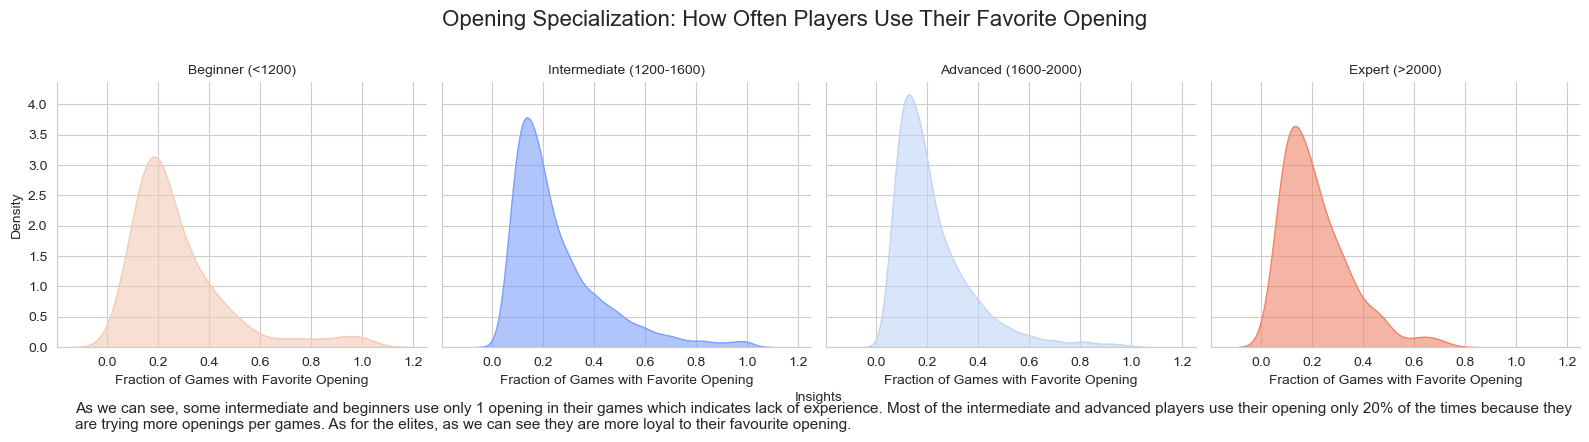

In [27]:


# 2. Re-calculate the Favorite Openings + Totals (Standardizing the logic)
# Count how many times each player played each opening
opening_counts = df.groupby(['White', 'Opening']).size().reset_index(name='Fav_Count')

# Get total games played as White for each player
total_counts = df.groupby('White').size().reset_index(name='Total_Games')

# Get average Elo per player
player_elo = df.groupby('White')['WhiteElo'].mean().reset_index(name='Avg_Elo')

# 3. Combine to find the Top-1 Favorite
# Sort by count and keep the highest for each player
fav_stats = opening_counts.sort_values(['White', 'Fav_Count'], ascending=[True, False])
fav_stats = fav_stats.drop_duplicates(subset=['White'], keep='first')

# Merge all data together
loyalty_df = pd.merge(fav_stats, total_counts, on='White')
loyalty_df = pd.merge(loyalty_df, player_elo, on='White')

# 4. Calculate the Fraction
loyalty_df['Loyalty_Fraction'] = loyalty_df['Fav_Count'] / loyalty_df['Total_Games']

# 5. Filter for significance
# We exclude players with < 10 games to avoid 100% loyalty from small samples
loyalty_df = loyalty_df[loyalty_df['Total_Games'] >= 10]

# 6. Define Skill Levels
def get_skill_label(elo):
    if elo < 1200: return 'Beginner (<1200)'
    if elo < 1600: return 'Intermediate (1200-1600)'
    if elo < 2000: return 'Advanced (1600-2000)'
    return 'Expert (>2000)'

loyalty_df['Skill_Level'] = loyalty_df['Avg_Elo'].apply(get_skill_label)

# 7. Visualization: Density Plots (KDE) across Panels
sns.set_style("whitegrid")
level_order = ['Beginner (<1200)', 'Intermediate (1200-1600)', 'Advanced (1600-2000)', 'Expert (>2000)']

# Create FacetGrid
g = sns.FacetGrid(loyalty_df, col="Skill_Level", col_order=level_order, 
                  hue="Skill_Level", palette="coolwarm", height=4, aspect=1)

# Map the Density Plot
g.map(sns.kdeplot, "Loyalty_Fraction", fill=True, alpha=0.6, bw_adjust=1)

# Formatting
g.set_axis_labels("Fraction of Games with Favorite Opening", "Density")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Opening Specialization: How Often Players Use Their Favorite Opening", fontsize=16)

# --- Add Horizontal Line and Insights ---



# Add "Insights" label
plt.figtext(0.5, 0.002, "Insights", fontsize=10, ha='left')

# Add your specific analysis text
insight_text = (
    "As we can see, some intermediate and beginners use only 1 opening in their games which indicates lack of experience. "
    "Most of the intermediate and advanced players use their opening only 20% of the times because they are trying more "
    "openings per games. As for the elites, as we can see they are more loyal to their favourite opening."
)

plt.figtext(0.05, 0.000002, insight_text, fontsize=11, ha='left', va='top', wrap=True)

# Save and Show
save_path = r"D:\Chess\opening_loyalty_density_panels.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()

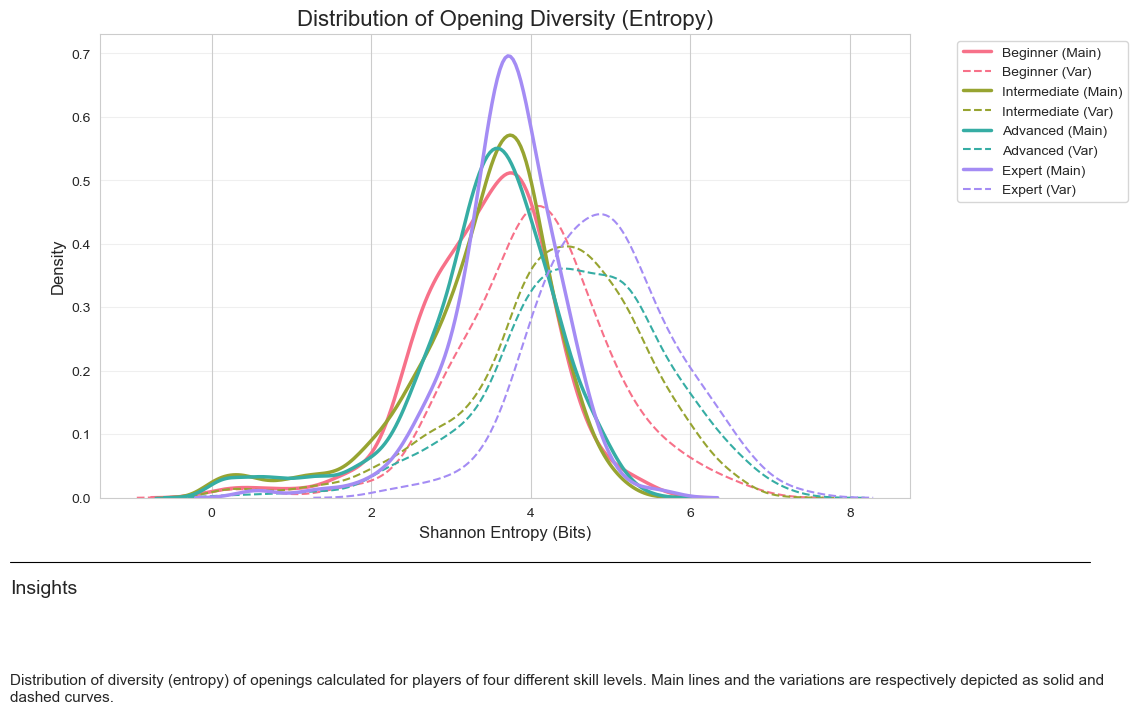

In [30]:
df['MainLine'] = df['Opening'].str.split(':').str[0]
df['Variation'] = df['Opening']

# 3. Calculate Dual Entropies per Player
player_data = []
for player, group in df.groupby('White'):
    if len(group) < 20: continue
    
    # Entropy of Main Lines
    main_counts = group['MainLine'].value_counts(normalize=True)
    h_main = entropy(main_counts, base=2)
    
    # Entropy of Variations
    var_counts = group['Variation'].value_counts(normalize=True)
    h_var = entropy(var_counts, base=2)
    
    avg_elo = group['WhiteElo'].mean()
    player_data.append({'H_Main': h_main, 'H_Var': h_var, 'Elo': avg_elo})

entropy_df = pd.DataFrame(player_data)

# 4. Categorize Skill
def get_skill(elo):
    if elo < 1200: return 'Beginner'
    if elo < 1600: return 'Intermediate'
    if elo < 2000: return 'Advanced'
    return 'Expert'

entropy_df['Skill'] = entropy_df['Elo'].apply(get_skill)

# 5. Visualization
plt.figure(figsize=(12, 8))
skills = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
colors = sns.color_palette("husl", 4)

for i, skill in enumerate(skills):
    subset = entropy_df[entropy_df['Skill'] == skill]
    
    # Solid line for Main Lines
    sns.kdeplot(subset['H_Main'], color=colors[i], label=f'{skill} (Main)', 
                linestyle='-', linewidth=2.5)
    
    # Dashed line for Variations
    sns.kdeplot(subset['H_Var'], color=colors[i], label=f'{skill} (Var)', 
                linestyle='--', linewidth=1.5)

plt.title("Distribution of Opening Diversity (Entropy)", fontsize=16)
plt.xlabel("Shannon Entropy (Bits)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

# Adjust layout to make room for the insights block
plt.subplots_adjust(bottom=0.3, right=0.8)

# --- Add Horizontal Line and Insights ---

# Add a divider line
line = plt.Line2D([0.05, 0.95], [0.22, 0.22], transform=plt.gcf().transFigure, color='black', linewidth=0.8)
plt.gcf().lines.append(line)

# Add "Insights" Header
plt.figtext(0.05, 0.18, "Insights", fontsize=14, ha='left')

# Add your specific text
insight_text = ("Distribution of diversity (entropy) of openings calculated for players of four different skill levels. "
                "Main lines and the variations are respectively depicted as solid and dashed curves.")

plt.figtext(0.05, 0.08, insight_text, fontsize=11, ha='left', va='top', wrap=True)

plt.savefig(r"D:\Chess\entropy_main_vs_var.png", bbox_inches='tight')
plt.show()

Is there a relationship between winning and the opening choice ?

In [17]:
from scipy.stats import chi2_contingency

# Create a cross-tabulation of Opening vs Result
# (Assuming 'Result' is '1-0', '0-1', or '1/2-1/2')
contingency_table = pd.crosstab(df['MainLine'], df['Result'])

# Run the test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Squared: {chi2}")
print(f"P-value: {p}")

if p < 0.05:
    print("✨ Result: There IS a significant relationship between opening and winning.")
else:
    print("Result: No significant relationship found.")

Chi-Squared: 45345.02823376197
P-value: 0.0
✨ Result: There IS a significant relationship between opening and winning.


2nd favourite opening analysis 

C:\Users\salma\AppData\Local\Temp\ipykernel_13224\18602939.py:6: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")


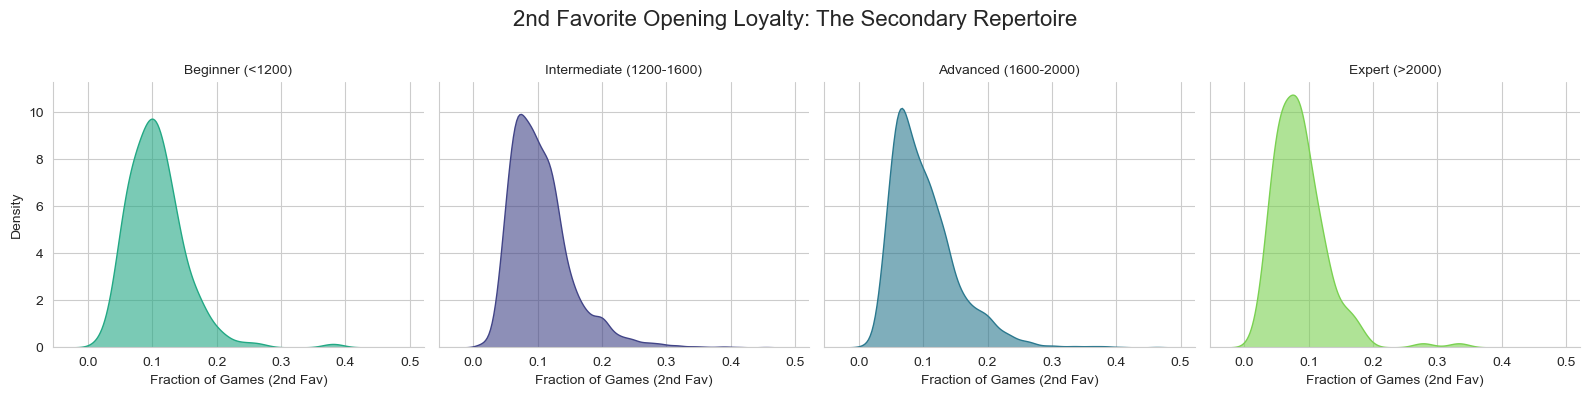

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")

# Ensure Elo is numeric (this prevents the TypeError later)
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')

# 2. Re-calculate the Repertoire Stats
# Count occurrences of each opening for each player
opening_counts = df.groupby(['White', 'Opening']).size().reset_index(name='Fav_Count')

# Get total games per player
total_counts = df.groupby('White').size().reset_index(name='Total_Games')

# FIX: Add numeric_only=True to prevent TypeError: agg function failed [how->mean]
player_elo = df.groupby('White')['WhiteElo'].mean(numeric_only=True).reset_index(name='Avg_Elo')

# 3. Find the 2nd Favorite Opening
# Sort by count descending within each player group
sorted_counts = opening_counts.sort_values(['White', 'Fav_Count'], ascending=[True, False])

# Pick the 2nd highest (index 1) for each player
# If a player has only one opening, they are automatically dropped here
second_fav = sorted_counts.groupby('White').nth(1)

# 4. Merge all data
loyalty_df_2nd = pd.merge(second_fav, total_counts, on='White')
loyalty_df_2nd = pd.merge(loyalty_df_2nd, player_elo, on='White')

# 5. Calculate Fraction and Filter
loyalty_df_2nd['Loyalty_Fraction'] = loyalty_df_2nd['Fav_Count'] / loyalty_df_2nd['Total_Games']
# We use a slightly higher threshold (15 games) to ensure a 2nd favorite actually exists
loyalty_df_2nd = loyalty_df_2nd[loyalty_df_2nd['Total_Games'] >= 15]

# 6. Define Skill Levels
def get_skill_label(elo):
    if elo < 1200: return 'Beginner (<1200)'
    if elo < 1600: return 'Intermediate (1200-1600)'
    if elo < 2000: return 'Advanced (1600-2000)'
    return 'Expert (>2000)'

loyalty_df_2nd['Skill_Level'] = loyalty_df_2nd['Avg_Elo'].apply(get_skill_label)

# 7. Visualization: Density Plots
sns.set_style("whitegrid")
level_order = ['Beginner (<1200)', 'Intermediate (1200-1600)', 'Advanced (1600-2000)', 'Expert (>2000)']

g = sns.FacetGrid(loyalty_df_2nd, col="Skill_Level", col_order=level_order, 
                  hue="Skill_Level", palette="viridis", height=4, aspect=1)

g.map(sns.kdeplot, "Loyalty_Fraction", fill=True, alpha=0.6, bw_adjust=1)

# Formatting
g.set_axis_labels("Fraction of Games (2nd Fav)", "Density")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("2nd Favorite Opening Loyalty: The Secondary Repertoire", fontsize=16)



# Save and Show
plt.savefig(r"D:\Chess\secondary_loyalty_density.png", bbox_inches='tight')
plt.show()

Encyclopedia of Chess Openings (ECO)

# The bipartite network of chess players and openings


In [3]:
df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")
print(df.columns.tolist())

C:\Users\salma\AppData\Local\Temp\ipykernel_19188\838281536.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")


['Event', 'Site', 'Date', 'Round', 'White', 'Black', 'Result', 'UTCDate', 'UTCTime', 'WhiteElo', 'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'ECO', 'Opening', 'TimeControl', 'Termination', 'Source_File', 'BlackTitle', 'WhiteTitle']


In [5]:
df.dtypes

Event               object
Site                object
Date                object
Round               object
White               object
Black               object
Result              object
UTCDate             object
UTCTime             object
WhiteElo            object
BlackElo            object
WhiteRatingDiff    float64
BlackRatingDiff    float64
ECO                 object
Opening             object
TimeControl         object
Termination         object
Source_File         object
BlackTitle          object
WhiteTitle          object
dtype: object

In [16]:
import pandas as pd

def build_bipartite_matrix(df):
    # 1. Filter for High-Rated games (Both players > 2000)
    # This ensures we are looking at the "Master" community
    df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
    df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')
    expert_df = df[(df['WhiteElo'] > 1500) & (df['BlackElo'] > 1500)].dropna(subset=['WhiteElo', 'BlackElo']).copy()

    # 2. Preparation: Create Color-coded Opening nodes
    # We use 'White' and 'Black' based on your column list
    white_games = expert_df[['White', 'ECO']].copy()
    white_games['Node'] = white_games['ECO'] + 'W'
    white_games.rename(columns={'White': 'Player'}, inplace=True)

    black_games = expert_df[['Black', 'ECO']].copy()
    black_games['Node'] = black_games['ECO'] + 'B'
    black_games.rename(columns={'Black': 'Player'}, inplace=True)

    # Combine into a participation list
    participation = pd.concat([white_games[['Player', 'Node']], black_games[['Player', 'Node']]])

    # 3. Filtering: Players with at least 100 games as White AND 100 as Black
    # We count based on the original expert_df to be accurate
    white_counts = expert_df['White'].value_counts()
    black_counts = expert_df['Black'].value_counts()
    
    valid_players = white_counts[(white_counts >= 100) & (black_counts.reindex(white_counts.index) >= 100)].dropna().index
    
    # Keep only the participation records for these specific players
    participation = participation[participation['Player'].isin(valid_players)]

    # 4. Create the P x O Matrix (Bi-adjacency Matrix)
    # Binary: 1 if the player played this opening, 0 otherwise
    matrix = pd.crosstab(participation['Player'], participation['Node'])
    matrix = (matrix > 0).astype(int)
    
    return matrix

# Execute with your loaded 'df'
adj_matrix = build_bipartite_matrix(df)

print(f"Matrix Shape: {adj_matrix.shape}")

Matrix Shape: (911, 934)


In [9]:
!pip install igraph

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------------- -------------------------- 1.0/3.2 MB 4.0 MB/s eta 0:00:01
   ---------------- ----------------------- 1.3/3.2 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 2.4/3.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 3.5 MB/s  0:00:01

   -------------------- ------------------- 1/2 [igraph]
   -------------------- ------------------- 1/2 [igraph]
   ---------------------------------------- 2/2 [igraph]



In [11]:
!pip install leidenalg

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 3.9 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.2 MB/s  0:00:00


In [18]:
import leidenalg as la
import igraph as ig

def tune_leiden_to_10_clusters(adj_matrix):
    # Create the projection
    projection = adj_matrix.dot(adj_matrix.T)
    np.fill_diagonal(projection.values, 0)
    
    # Create the graph
    sources, targets = np.where(projection > 0)
    weights = projection.values[sources, targets]
    g = ig.Graph(n=len(adj_matrix), edges=list(zip(sources, targets)), directed=False)
    g.es['weight'] = weights

    # Start with a standard resolution and "nudge" it up
    res = 1.0 
    clusters = 0
    attempts = 0
    
    print("Tuning resolution to find 10 clusters...")
    
    while clusters != 10 and attempts < 20:
        partition = la.find_partition(g, la.RBConfigurationVertexPartition, 
                                     weights=g.es['weight'], 
                                     resolution_parameter=res)
        clusters = len(set(partition.membership))
        print(f"Resolution: {res:.2f} -> Clusters found: {clusters}")
        
        if clusters < 10:
            res *= 1.5  # Increase resolution to get MORE clusters
        elif clusters > 10:
            res *= 0.8  # Decrease resolution to get FEWER clusters
            
        attempts += 1
        if clusters == 10:
            break

    player_clusters = pd.DataFrame({
        'Player': adj_matrix.index,
        'Cluster': partition.membership
    })
    
    return player_clusters, partition

# Run it
clusters_df, final_partition = tune_leiden_to_10_clusters(adj_matrix)

Tuning resolution to find 10 clusters...
Resolution: 1.00 -> Clusters found: 3
Resolution: 1.50 -> Clusters found: 373
Resolution: 1.20 -> Clusters found: 87
Resolution: 0.96 -> Clusters found: 2
Resolution: 1.44 -> Clusters found: 315
Resolution: 1.15 -> Clusters found: 52
Resolution: 0.92 -> Clusters found: 2
Resolution: 1.38 -> Clusters found: 265
Resolution: 1.11 -> Clusters found: 23
Resolution: 0.88 -> Clusters found: 2
Resolution: 1.33 -> Clusters found: 208
Resolution: 1.06 -> Clusters found: 10


In [20]:
def identify_cluster_signatures(adj_matrix, clusters_df):
    signatures = {}
    
    for cluster_id in range(10):
        # Get players in this specific cluster
        cluster_players = clusters_df[clusters_df['Cluster'] == cluster_id]['Player']
        
        # Calculate the popularity of each opening WITHIN this cluster
        cluster_data = adj_matrix.loc[cluster_players]
        opening_frequencies = cluster_data.mean().sort_values(ascending=False)
        
        # Take the Top 5 most "defining" openings for this group
        signatures[f"Cluster {cluster_id}"] = opening_frequencies.head(5).index.tolist()
        
    return pd.DataFrame(signatures)

# Execute
cluster_labels = identify_cluster_signatures(adj_matrix, clusters_df)
print(cluster_labels)

  Cluster 0 Cluster 1 Cluster 2 Cluster 3 Cluster 4 Cluster 5 Cluster 6  \
0      A00B      A00B      A00B      A00B      A00B      A00B      A00B   
1      A40W      C00W      C00W      A40B      D00W      B21W      C20B   
2      A43W      B00W      B00W      A00W      B01W      A01B      B06W   
3      A41W      C20B      B01W      B00B      C00W      D06B      B07W   
4      A01B      B01W      B06W      A04B      C20B      D02B      B20B   

  Cluster 7 Cluster 8 Cluster 9  
0      A00B      A00B      A00B  
1      C02W      C44W      C45W  
2      D02B      A42B      C00W  
3      D00B      A41W      C01B  
4      C50W      A40W      C01W  


Calculating Force-Directed Layout...


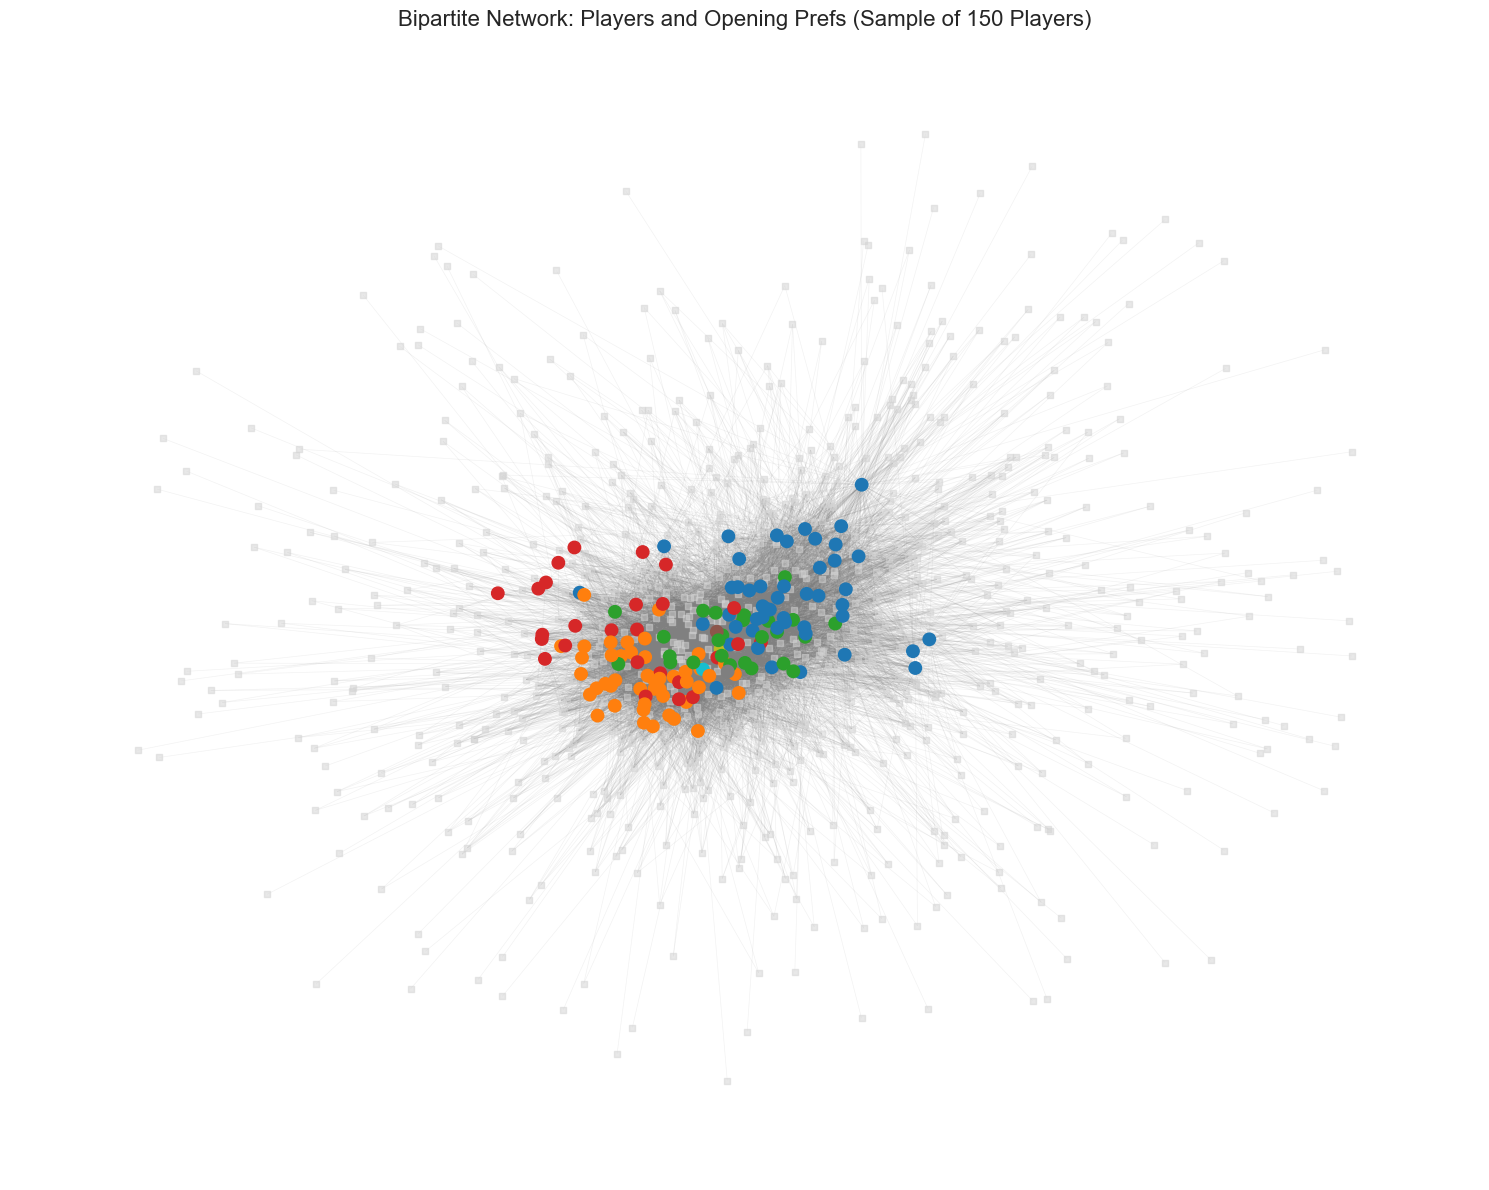

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_bipartite_network(adj_matrix, clusters_df, sample_size=100):
    # 1. Sub-sample for visual clarity (Optional but recommended)
    # Taking a random sample of players to avoid a "hairball" effect
    sampled_players = clusters_df.sample(sample_size)
    sampled_matrix = adj_matrix.loc[sampled_players['Player']]
    
    # 2. Create the Graph
    G = nx.Graph()
    
    # Add Player Nodes
    for _, row in sampled_players.iterrows():
        G.add_node(row['Player'], node_type='player', cluster=row['Cluster'])
    
    # Add Opening Nodes and Edges
    for player in sampled_matrix.index:
        # Get openings played by this player (where value is 1)
        openings = sampled_matrix.columns[sampled_matrix.loc[player] == 1]
        for opening in openings:
            G.add_node(opening, node_type='opening')
            G.add_edge(player, opening)

    # 3. Define Layout (Force-Directed)
    print("Calculating Force-Directed Layout...")
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    # 4. Draw the Network
    plt.figure(figsize=(15, 12))
    
    # Identify node types for different styling
    player_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'player']
    opening_nodes = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'opening']
    
    # Get colors based on Cluster ID for players
    cluster_colors = [G.nodes[n]['cluster'] for n in player_nodes]
    
    # Draw Openings (Small, grey squares)
    nx.draw_networkx_nodes(G, pos, nodelist=opening_nodes, node_size=20, 
                           node_color='lightgrey', node_shape='s', alpha=0.5)
    
    # Draw Players (Larger, colored circles based on Leiden Cluster)
    nx.draw_networkx_nodes(G, pos, nodelist=player_nodes, node_size=80, 
                           node_color=cluster_colors, cmap=plt.cm.tab10)
    
    # Draw Edges (Very thin, transparent lines)
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='grey', width=0.5)

    plt.title(f"Bipartite Network: Players and Opening Prefs (Sample of {sample_size} Players)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('chess_bipartite_network.png', dpi=300)
    plt.show()

# Execute
visualize_bipartite_network(adj_matrix, clusters_df, sample_size=150)